<a href="https://colab.research.google.com/github/chavezgranados/Quantitative-Methods/blob/main/notebooks/cuaderno3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<font face="gotham" color="#1B5E20"> Unidad de Posgrado de la Facultad de Economía </font>

<img src="https://yachay.digital/wp-content/uploads/2021/03/uncp.png" width="120">

<font face="gotham" color="#1B5E20"> **Curso: Métodos Cuantitativos Aplicados a la Investigación** </font>

<hr width="50%" color="#C9A227">

<font face="gotham" color="#1B5E20"> Maestría en Planificación y Proyectos de Inversión </font>

<font face="gotham" color="#1B5E20"> `Luis Chávez` </font>

<font face="gotham" color="#1B5E20"> 2026 </font>

# <font face="gotham" color="#E3B10D"> **Tópico: transformación de datos**

In [1]:
# Preámbulo
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import PowerTransformer # transformación moderna

In [2]:
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
datos = pd.read_csv(url)
datos

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


In [3]:
# Renombrar variables
# ==============================================================================
datos.rename(columns={"Siblings/Spouses Aboard": "HermanosConyuges","Parents/Children Aboard": "PadresHijos"}, inplace=True)

In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Survived          887 non-null    int64  
 1   Pclass            887 non-null    int64  
 2   Name              887 non-null    object 
 3   Sex               887 non-null    object 
 4   Age               887 non-null    float64
 5   HermanosConyuges  887 non-null    int64  
 6   PadresHijos       887 non-null    int64  
 7   Fare              887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [5]:
datos["Sex"].unique()

array(['male', 'female'], dtype=object)

## **1. Conversión de tipos de datos**

In [6]:
#datos["varname"] = pd.to_numeric(datos["varname"], errors="coerce") # string a num

In [7]:
datos["Sex"] = datos["Sex"].astype("category")               # num a categórico
datos["Survived"] = datos["Survived"].astype("category")
datos["Pclass"] = datos["Pclass"].astype("category")

In [8]:
datos["Name"] = datos["Name"].astype("string") # object a string

In [9]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Survived          887 non-null    category
 1   Pclass            887 non-null    category
 2   Name              887 non-null    string  
 3   Sex               887 non-null    category
 4   Age               887 non-null    float64 
 5   HermanosConyuges  887 non-null    int64   
 6   PadresHijos       887 non-null    int64   
 7   Fare              887 non-null    float64 
dtypes: category(3), float64(2), int64(2), string(1)
memory usage: 37.7 KB


## **2. Creación de nuevas variables**

In [10]:
datos["LogFare"] = np.log(datos["Fare"] + 1)

In [11]:
datos["ViajaSolo"] = np.where((datos["HermanosConyuges"] == 0) &
    (datos["PadresHijos"] == 0), "si", "no")

In [12]:
datos["ViajaSolo"].value_counts()

,count
ViajaSolo,
si,533
no,354


## **3. Recodificación de datos**

In [13]:
datos["Sex"] = datos["Sex"].cat.rename_categories({"male": "varon", "female": "mujer"})

In [14]:
datos["Sex"].cat.categories # 0 mujer, 1 varón

Index(['mujer', 'varon'], dtype='object')

In [15]:
datos["Sex"].value_counts()

,count
Sex,
varon,573
mujer,314


In [16]:
datos["Survived"] = datos["Survived"].cat.rename_categories({0: "no",  1: "si"})

In [17]:
datos["Survived"].cat.categories

Index(['no', 'si'], dtype='object')

In [18]:
datos["Pclass"] = datos["Pclass"].cat.rename_categories({1: "Primera", 2: "Segunda", 3: "Tercera"})

In [19]:
datos["Pclass"].cat.categories

Index(['Primera', 'Segunda', 'Tercera'], dtype='object')

## **4. Discretización**

In [20]:
datos["AgeGroup"] = pd.cut(datos["Age"], bins=[0, 12, 18, 60, 100],
                           labels=["infante", "adolescente", "adulto", "mayor"])

In [21]:
datos["AgeGroup"].value_counts()

,count
AgeGroup,
adulto,695
adolescente,87
infante,79
mayor,26


In [22]:
datos["FareGroup"] = pd.cut(datos["Fare"], bins=[0, 10, 30, 100, 600],
                            labels=["economica", "media", "alta", "vip"],
                            include_lowest=True) # include_lowest=True permite que lim inferior sea cerrado de l primer intervalo

## **5. Normalización y estandarización**

Estandarización:

$z=\dfrac{x-\mu}{\sigma}$

In [23]:
scaler = StandardScaler()
datos[["Age_z", "Fare_z"]] = scaler.fit_transform(datos[["Age", "Fare"]])


Normalización:

$x=\dfrac{x-min}{max-min}$

In [24]:
scaler = MinMaxScaler()
datos[["Age_norm", "Fare_norm"]] = scaler.fit_transform(datos[["Age", "Fare"]])

In [25]:
datos.head()

,Survived,Pclass,Name,Sex,Age,HermanosConyuges,PadresHijos,Fare,LogFare,ViajaSolo,AgeGroup,FareGroup,Age_z,Fare_z,Age_norm,Fare_norm
0,no,Tercera,Mr. Owen Harris Braund,varon,22.0,1,0,7.2500,2.110213,no,adulto,economica,-0.529366,-0.503586,0.271174,0.014151
1,si,Primera,Mrs. John Bradley (Florence Briggs Thayer) Cum...,mujer,38.0,1,0,71.2833,4.280593,no,adulto,alta,0.604265,0.783412,0.472229,0.139136
2,si,Tercera,Miss. Laina Heikkinen,mujer,26.0,0,0,7.9250,2.188856,si,adulto,economica,-0.245958,-0.490020,0.321438,0.015469
3,si,Primera,Mrs. Jacques Heath (Lily May Peel) Futrelle,mujer,35.0,1,0,53.1000,3.990834,no,adulto,alta,0.391709,0.417948,0.434531,0.103644
4,no,Tercera,Mr. William Henry Allen,varon,35.0,0,0,8.0500,2.202765,si,adulto,economica,0.391709,-0.487507,0.434531,0.015713


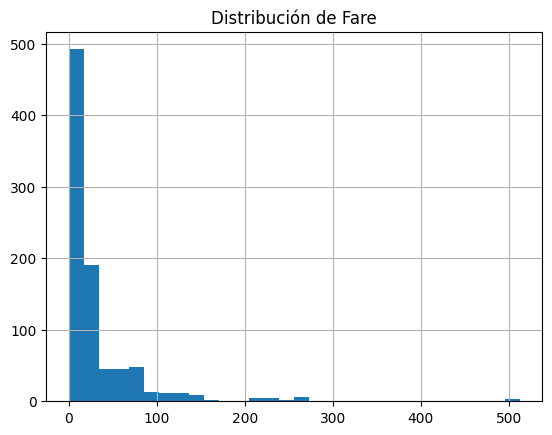

In [26]:
datos["Fare"].hist(bins=30)
plt.title("Distribución de Fare")
plt.show()

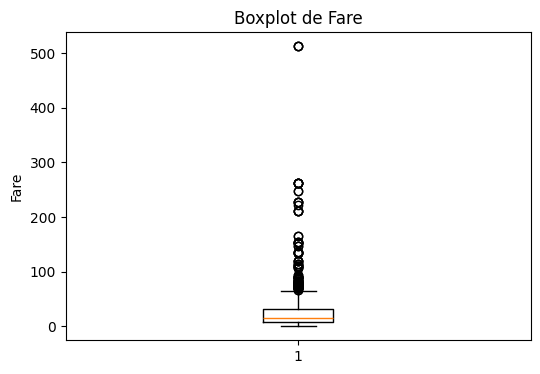

In [27]:
plt.figure(figsize=(6,4))
plt.boxplot(datos["Fare"], vert=True)
plt.title("Boxplot de Fare")
plt.ylabel("Fare")
plt.show()

In [28]:
datos["Fare_boxcox"], lambda_ = stats.boxcox(datos["Fare"] + 1)

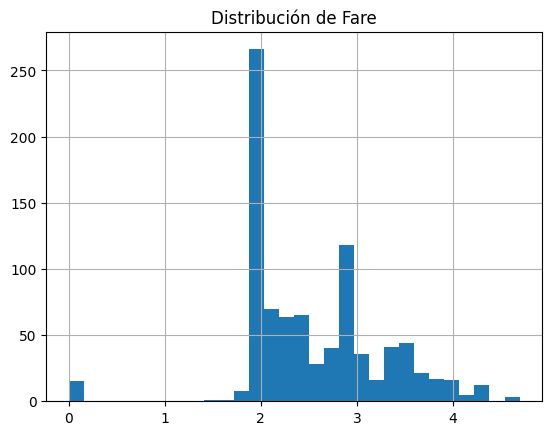

In [29]:
datos["Fare_boxcox"].hist(bins=30)
plt.title("Distribución de Fare")
plt.show()

In [30]:
pt = PowerTransformer(method="yeo-johnson") # no necesita de valores positivos
datos["Fare_yj"] = pt.fit_transform(datos[["Fare"]])

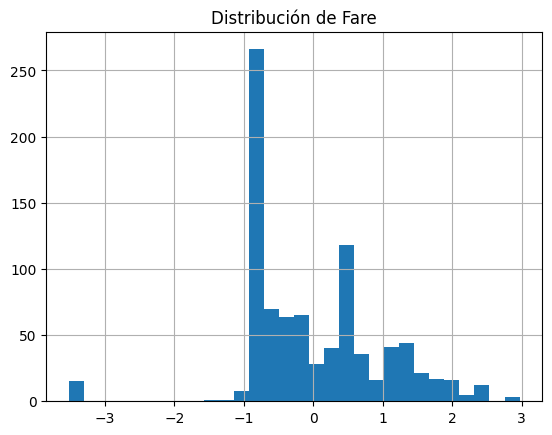

In [31]:
datos["Fare_yj"].hist(bins=30)
plt.title("Distribución de Fare")
plt.show()


> **Exportar**


In [32]:
datos.to_csv('titanic_tr.csv', index=False, encoding='utf-8') # a veces no recomendado

In [33]:
datos.to_parquet("titanic_tr.parquet") # a veces recomendado

In [34]:
datos.to_pickle("titanic_tr.pkl") # a veces recomendado